In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [9]:
class PinholeCamera():
    def __init__(self, K : np.ndarray ,dist_coefs : np.ndarray, world_R_cam : np.ndarray  , world_t_cam : np.ndarray ):
        self.K = K
        self.dist_coefs = dist_coefs
        self.world_R_cam = world_R_cam
        self.world_t_cam = world_t_cam
        self.world_T_cam = np.eye(4)
        self.world_T_cam[:3, :3] = world_R_cam
        self.world_T_cam[:3, 3] = world_t_cam.flatten()

    def project(self, world_pts_3d: np.ndarray) -> np.ndarray:
        n = world_pts_3d.shape[0]
        pts_homo = np.hstack((world_pts_3d, np.ones((n, 1))))
        cam_T_world = np.linalg.inv(self.world_T_cam)
        pts_cam = (cam_T_world @ pts_homo.T).T

        z = pts_cam[:, 2:3]
        z[z<=0] = 1e-6
        pts_2d_norm = pts_cam[:, :2] / z

        x = pts_2d_norm[:, 0]
        y = pts_2d_norm[:, 1]
        r2 = x**2 + y**2
        k1, k2, p1, p2, k3 = self.dist_coefs

        radial = (1 + k1*r2 + k2*r2**2 + k3*r2**3)
        x_dist = x * radial + (2*p1*x*y + p2*(r2 + 2*x**2))
        y_dist = y * radial + (p1*(r2 + 2*y**2) + 2*p2*x*y)

        pts_dist_homo = np.stack((x_dist, y_dist, np.ones_like(x_dist)), axis=1)
        pixels = (self.K @ pts_dist_homo.T).T
        return pixels[:, :2]

    def unproject(self, image_pts_2d: np.ndarray) -> np.ndarray:
        n = image_pts_2d.shape[0]
        pixels_homo = np.hstack((image_pts_2d, np.ones((n, 1))))
        K_inv = np.linalg.inv(self.K)
        pts_dist = (K_inv @ pixels_homo.T).T

        x_d = pts_dist[:, 0]
        y_d = pts_dist[:, 1]
        x, y = x_d, y_d
        k1, k2, p1, p2, k3 = self.dist_coefs

        for _ in range(5):
            r2 = x**2 + y**2
            radial = (1 + k1*r2 + k2*r2**2 + k3*r2**3)
            dx = 2*p1*x*y + p2*(r2 + 2*x**2)
            dy = p1*(r2 + 2*y**2) + 2*p2*x*y
            x = (x_d - dx) / radial
            y = (y_d - dy) / radial

        rays_cam = np.stack((x, y, np.ones_like(x)), axis=1)
        rays_world = (self.world_R_cam @ rays_cam.T).T
        return rays_world / np.linalg.norm(rays_world, axis=1, keepdims=True)

In [4]:
class PnP():
  def __init__(self, world_pts, cam_pts, K, dist_coeffs):
    self.world_pts = world_pts
    self.cam_pts = cam_pts
    self.K = K
    self.dist_coefs = dist_coeffs

  def get_pose(self):
    _, rvec, tvec = cv2.solvePnP(self.world_pts,self.cam_pts,self.K,self.dist_coefs)

    cam_R_world, _ = cv2.Rodrigues(rvec)
    cam_t_world = tvec.flatten()

    cam_T_world = np.eye(4)
    cam_T_world[:3,:3] = cam_R_world
    cam_T_world[:3,3] = cam_t_world

    world_T_cam = np.linalg.inv(cam_T_world)

    return world_T_cam


--- RESULTS ---
Real Position (GT) : [ 0.  0. -2.]
Estimated Position  : [-0. -0. -2.]
Position error   : 0.00000022 m

Real Orientation (GT) : [[ 0.9848  0.     -0.1736]
 [ 0.      1.      0.    ]
 [ 0.1736  0.      0.9848]]
Estimated Orientation  : [[ 0.9848 -0.     -0.1736]
 [ 0.      1.      0.    ]
 [ 0.1736 -0.      0.9848]]
Orientation error   : 0.00000005 rad



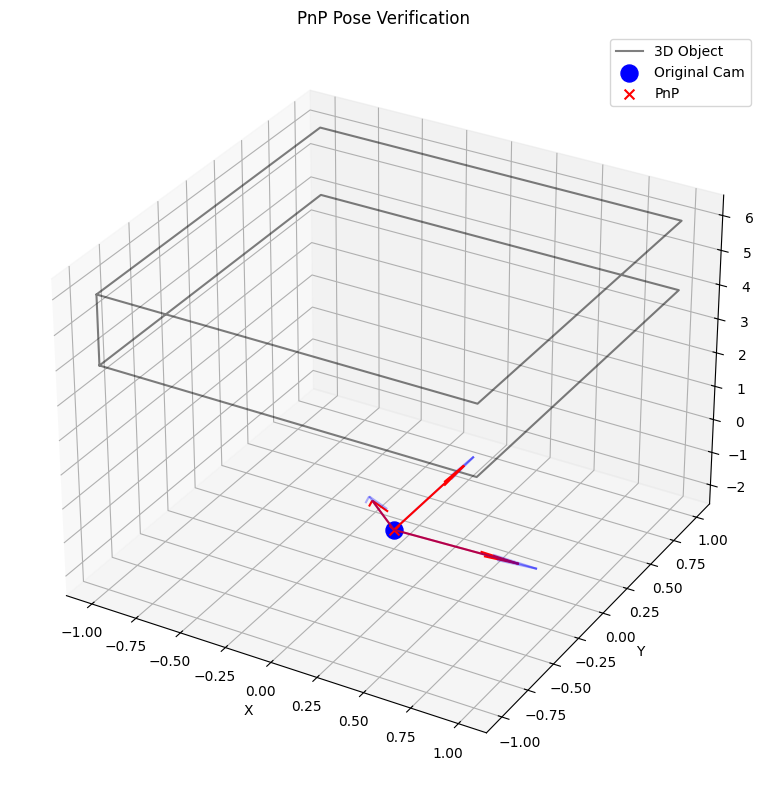

In [21]:
# ==========================================
# Case tests - AI Generated
# ==========================================
def run_pnp_test():
    K = np.array([[800, 0, 320], [0, 800, 240], [0, 0, 1]])
    dist = np.zeros(5)

    gt_t = np.array([0.0, 0.0, -2.0])

    theta = np.radians(-10)
    gt_R = np.array([
        [np.cos(theta),  0, np.sin(theta)],
        [0,              1, 0            ],
        [-np.sin(theta), 0, np.cos(theta)]
    ])

    obj_3d = np.array([
        [-1,-1,4], [1,-1,4], [1,1,4], [-1,1,4], [-1,-1,4],
        [-1,-1,6], [1,-1,6], [1,1,6], [-1,1,6], [-1,-1,6]
    ])

    cam_virtual = PinholeCamera(K, dist, gt_R, gt_t)

    pts_2d_projetados = cam_virtual.project(obj_3d)

    pnp_solver = PnP(obj_3d, pts_2d_projetados, K, dist)

    estimated_T = pnp_solver.get_pose()

    est_R = estimated_T[:3, :3]
    est_t = estimated_T[:3, 3]

    position_error = np.linalg.norm(gt_t - est_t)
    orientation_error = np.linalg.norm(gt_R - est_R)
    print("\n--- RESULTS ---")
    print(f"Real Position (GT) : {np.round(gt_t, 4)}")
    print(f"Estimated Position  : {np.round(est_t, 4)}")
    print(f"Position error   : {position_error:.8f} m\n")

    print(f"Real Orientation (GT) : {np.round(gt_R, 4)}")
    print(f"Estimated Orientation  : {np.round(est_R, 4)}")
    print(f"Orientation error   : {orientation_error:.8f} rad\n")



    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot(obj_3d[:,0], obj_3d[:,1], obj_3d[:,2], 'k-', label='3D Object', alpha=0.5)

    ax.scatter(*gt_t, color='blue', s=150, label='Original Cam', marker='o')
    for i, c in enumerate(['b', 'b', 'b']):
        ax.quiver(*gt_t, *(gt_R[:, i]*0.8), color=c, alpha=0.3)

    ax.scatter(*est_t, color='red', s=50, label='PnP', marker='x')
    for i, c in enumerate(['r', 'r', 'r']):
        ax.quiver(*est_t, *(est_R[:, i]*0.7), color=c)

    ax.set_title("PnP Pose Verification")
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.legend()
    plt.tight_layout()
    plt.show()

run_pnp_test()